# CS156 Session 6: Maximum Likelihood and Logistic Regression

Fitting a logistic regression by maximum likelihood on a synthetic "Bollywood" dataset: hours of training (in 1000s) vs. whether someone landed a role. The true parameters are beta_0 = -5 and beta_1 = 3, but we pretend not to know them.

My written answers are in `session6_workbook.md`.

Notes on this notebook:
- Cells marked "added" are additions to the workbook code.
- `np.random.seed(0)` was added so the data and numbers are reproducible. They will differ from the values in my submitted workbook run.
- The JAX cell at the end was **not run** here, because JAX isn't available in my environment. Run it in Colab to get its output.

## The data

In [1]:
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

np.random.seed(0)   # added, for reproducibility

NUM_DATAPOINTS = 1000

def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

def generate_data(x):
    a = 3  #beta_1
    b = -5  #beta_0
    prob = sigmoid(a*x+b)
    return np.random.uniform() < prob

x_data = np.random.uniform(high=3, size=NUM_DATAPOINTS)
y_data = [generate_data(x) for x in x_data]

print(y_data[:10],'\n', x_data[:10])

[False, True, True, False, True, False, False, True, True, False] 
 [1.64644051 2.1455681  1.80829013 1.63464955 1.2709644  1.93768234
 1.31276163 2.675319   2.89098828 1.15032456]


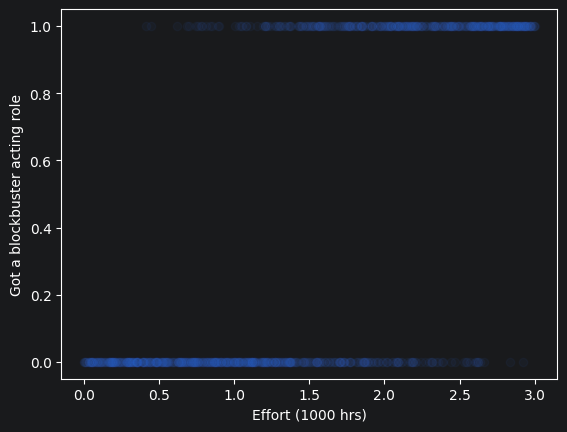

In [2]:
plt.scatter(x_data, y_data, alpha=0.05)
plt.xlabel("Effort (1000 hrs)")
plt.ylabel("Got a blockbuster acting role")
plt.show()

## Log-likelihood: Aishwarya vs. Irhum

Aishwarya claims beta_0 = 3, beta_1 = -3. Irhum claims beta_0 = 4, beta_1 = -1. Both are wrong. Which is more wrong? The higher log-likelihood is better.

### Why the submitted `log_likelihood_per_point` gave wrong numbers

The workbook version tested `if y is True`. The values in `y_data` come from a NumPy comparison, so they are `numpy.bool_`, not Python `True`, and `is True` is never satisfied. Every point fell into the `else` branch, which also had the wrong formula: `(1-y)*np.log(prob)` where it should be `np.log(1 - prob)`. The cell below shows the first problem (added).

In [3]:
# added: why `y is True` never matches
y_true_example = next(y for y in y_data if y)   # the first label that is True
print(type(y_true_example))
print("value:", y_true_example)
print("is True: ", y_true_example is True)    # False, even though the value is True
print("== True:  ", y_true_example == True)   # True

<class 'numpy.bool_'>
value: True
is True:  False
== True:   True


### The corrected function

The per-point term is `log(prob)` when the label is True and `log(1 - prob)` when it is False.

In [4]:
def log_likelihood_per_point(beta_0, beta_1, x, y):
    prob = sigmoid(beta_1*x + beta_0)
    if y:                          # works for Python bools and numpy bools
        return np.log(prob)
    else:
        return np.log(1 - prob)    # was (1-y)*np.log(prob) in the submitted version


# This one's complete!
def total_log_likelihood(beta_0, beta_1, xs, ys):
    total_ll = 0

    for (x, y) in zip(xs, ys):
        total_ll += log_likelihood_per_point(beta_0, beta_1, x, y)

    return total_ll

# Be careful, which is the *higher* value when two values are negative?
aishwarya = total_log_likelihood(3, -3, x_data, y_data)
irhum = total_log_likelihood(4, -1, x_data, y_data)
print("Aishwarya (beta_0=3, beta_1=-3):", aishwarya)
print("Irhum     (beta_0=4, beta_1=-1):", irhum)
print("Irhum has the higher (better) log-likelihood:", irhum > aishwarya)

# added: the true values, for reference
print("True values (beta_0=-5, beta_1=3):", total_log_likelihood(-5, 3, x_data, y_data))

Aishwarya (beta_0=3, beta_1=-3): -2218.853921562873
Irhum     (beta_0=4, beta_1=-1): -1856.9341899512276
Irhum has the higher (better) log-likelihood: True
True values (beta_0=-5, beta_1=3): -379.21373592634166


## Gradient of the log-likelihood

The gradient tells us which direction to adjust the estimates to increase the log-likelihood, starting from Aishwarya's estimate. The label vector is converted to 0s and 1s, and the log-likelihood is computed for all points in one call.

For logistic regression the gradient has a closed form, with p_i the predicted probability for point i:

```
d(logL)/d(beta_0) = sum_i (y_i - p_i)
d(logL)/d(beta_1) = sum_i (y_i - p_i) * x_i
```

The next cell (added) computes that and checks it against a finite-difference estimate. The JAX cell after it computes the same gradient automatically.

In [5]:
y_vec = np.array(y_data, dtype=float)    # True/False -> 1.0/0.0

def total_ll_vec(beta_0, beta_1, x, y):
    prob = 1 / (1 + np.exp(-(beta_1*x + beta_0)))
    return np.sum(y*np.log(prob) + (1-y)*np.log(1-prob))

def grad_ll(beta_0, beta_1, x, y):
    prob = 1 / (1 + np.exp(-(beta_1*x + beta_0)))
    resid = y - prob
    return np.array([np.sum(resid), np.sum(resid * x)])   # [d/d beta_0, d/d beta_1]

# vectorized version matches the loop version
print("loop:      ", total_log_likelihood(3, -3, x_data, y_data))
print("vectorized:", total_ll_vec(3, -3, x_data, y_vec))

g = grad_ll(3, -3, x_data, y_vec)
print("gradient at Aishwarya's estimate [d/d beta_0, d/d beta_1]:", g)

# finite-difference check
eps = 1e-6
fd0 = (total_ll_vec(3+eps, -3, x_data, y_vec) - total_ll_vec(3-eps, -3, x_data, y_vec)) / (2*eps)
fd1 = (total_ll_vec(3, -3+eps, x_data, y_vec) - total_ll_vec(3, -3-eps, x_data, y_vec)) / (2*eps)
print("finite differences:                                       ", np.array([fd0, fd1]))

loop:       -2218.853921562873
vectorized: -2218.8539215628716
gradient at Aishwarya's estimate [d/d beta_0, d/d beta_1]: [ 77.78187143 702.8570254 ]
finite differences:                                        [ 77.78187137 702.85702532]


### The same gradient with JAX (not run here)

Two fixes to the submitted cell: `bebta_1` was a typo for `beta_1`, which would raise a `NameError`, and the submitted cell never called `jax.grad`, so it never computed a gradient. Both are fixed below. The output should match the NumPy gradient above, up to JAX's default 32-bit precision.

In [6]:
%pip install jax[cpu]
import jax
import jax.numpy as jnp

y_data = np.array(y_data, dtype=float)

def sigmoid(z):
    return 1/ (1+jnp.exp(-z))

def total_log_likelihood(params, x, y):
    beta_0, beta_1 = params
    prob = sigmoid(beta_1 * x + beta_0)     # was "bebta_1" in the submitted version
    per_point = y * jnp.log(prob) + (1-y) * jnp.log(1-prob)
    return jnp.sum(per_point)

# added: gradient w.r.t. params = (beta_0, beta_1), at Aishwarya's estimate
grad_fn = jax.grad(total_log_likelihood)
print(grad_fn(jnp.array([3.0, -3.0]), x_data, y_data))

zsh:1: no matches found: jax[cpu]
Note: you may need to restart the kernel to use updated packages.
[ 77.78186 702.85706]
